In [1]:
import requests
from bs4 import BeautifulSoup
import json
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def lade_html(url) -> str:
    if url.startswith("/"):
        url = "https://de.wikipedia.org" + url
    return requests.get(url).text

def lade_seite(url):
    return BeautifulSoup(lade_html(url), features="html.parser").body

def get_table(url):
    body = lade_seite(url)
    tables = body.find_all("table")
    tables = list(filter(lambda tab: "class" in tab.attrs and "infobox" in tab["class"], tables))
    if len(tables) == 0:
        return None
    else:
        return tables[0]

def get_table_value(table, argument):
    for line in table.find_all("tr"):
        cells = line.find_all("td")
        if len(cells) != 2:
            continue
        param = cells[0].text\
                        .replace("\n", "")\
                        .replace("\t", "")\
                        .replace(":", "")
        if param == argument:
            return cells[1]

def get_links(cell):
    if cell is None:
        return
    links = cell.find_all("a")
    for a in links:
        if a.parent.name == "sup":
            continue
        if a["href"].startswith("/"):
            yield a.text, a["href"]

def get_infos(name, url, queue, output):
    if url in queue:
        del queue[url]
    infos = {"name": name, "von": [], "zu": []}
    table = get_table(url)
    if table is None:
        return infos
    von = get_links(get_table_value(table, "Beeinflusst von"))
    zu = get_links(get_table_value(table, "Beeinflusste"))
    for key, values in zip(["von", "zu"], [von, zu]):
        for name_, url_ in values:
            infos[key].append(url_)
            if url_ not in queue and url_ not in output:
                queue[url_] = name_
    print(name)
    return infos

In [3]:
queue = {"/wiki/Python_(Programmiersprache)": "Python"}
ausgabe = {}

while len(queue) > 0:
    url = list(queue.keys())[0]
    ausgabe[url] = get_infos(queue[url], url, queue, ausgabe)

with open("sprachen.json", "w") as f:
    json.dump(ausgabe, f, indent=2)

Python
ABC
C
C++
Perl
Java
Lisp
Haskell
APL
Dylan
Standard ML
Ruby
Cython
B
BCPL
C−−
C#
Objective-C
D
Go
JavaScript
PHP
Vala
Seed7
Ada
Ada 95
Rust
Pascal
Raku
Smalltalk
Windows PowerShell
Object Pascal
Oberon
Eiffel
Groovy
Clojure
Scala
ActionScript
Kotlin
Fortran
Logo
Mathematica
REBOL
Snap! / BYOB
LISP
Miranda
Clean
Curry
F#
Swift
J
Matlab
R
S
Scheme
Ocaml
Crystal
Elixir
BCPL
CPL
Cω
J#
Visual Basic
VB.NET
Newsqueak
Alef
Limbo
Self
Lua
Haxe
CoffeeScript
Dart
TypeScript
Tcl
HTML
Boo
Modula-2
PL/SQL
Cyclone
Erlang
Objective CAML
ALGOL
AppleScript
NewtonScript
Strongtalk
Turbo Pascal
.Net-Framework
C/AL
Component Pascal
Active Oberon
Zonnon
Prolog
Common Lisp
Oz
Gosu
Scratch
Forth
JSON
Objective CAML
Elm
LiveScript
S
Julia
Racket
Caml
ATS
QuickBASIC
Gambas
Stackless Python
Modula
Squirrel
YAML
Modula-2+
MATLAB
Mercury
Squeak
Etoys
HyperCard
Catrobat
App Inventor
Factor
PostScript
Caml


In [8]:
with open("sprachen.json", "r") as f:
    ausgabe = json.load(f)
kanten = []
counter = {sprache: 0 for sprache in [e["name"] for e in ausgabe.values()]}
G = nx.DiGraph()
for url in ausgabe:
    name = ausgabe[url]["name"]
    neue_kanten = []
    for url_ in ausgabe[url]["von"]:
        neue_kanten.append((ausgabe[url_]["name"], name))
    for url_ in ausgabe[url]["zu"]:
        neue_kanten.append((name, ausgabe[url_]["name"]))
    for von, zu in neue_kanten:
        if (von, zu) not in kanten:
            kanten.append((von, zu))
            counter[von] += 1
            counter[zu] += 1

MINIMUM_COUNT = 8

for url in ausgabe:
    name = ausgabe[url]["name"]
    if counter[name] >= MINIMUM_COUNT:
        G.add_node(name)
for von, zu in kanten:
    if counter[von] >= MINIMUM_COUNT and counter[zu] >= MINIMUM_COUNT:
        G.add_edge(von, zu)

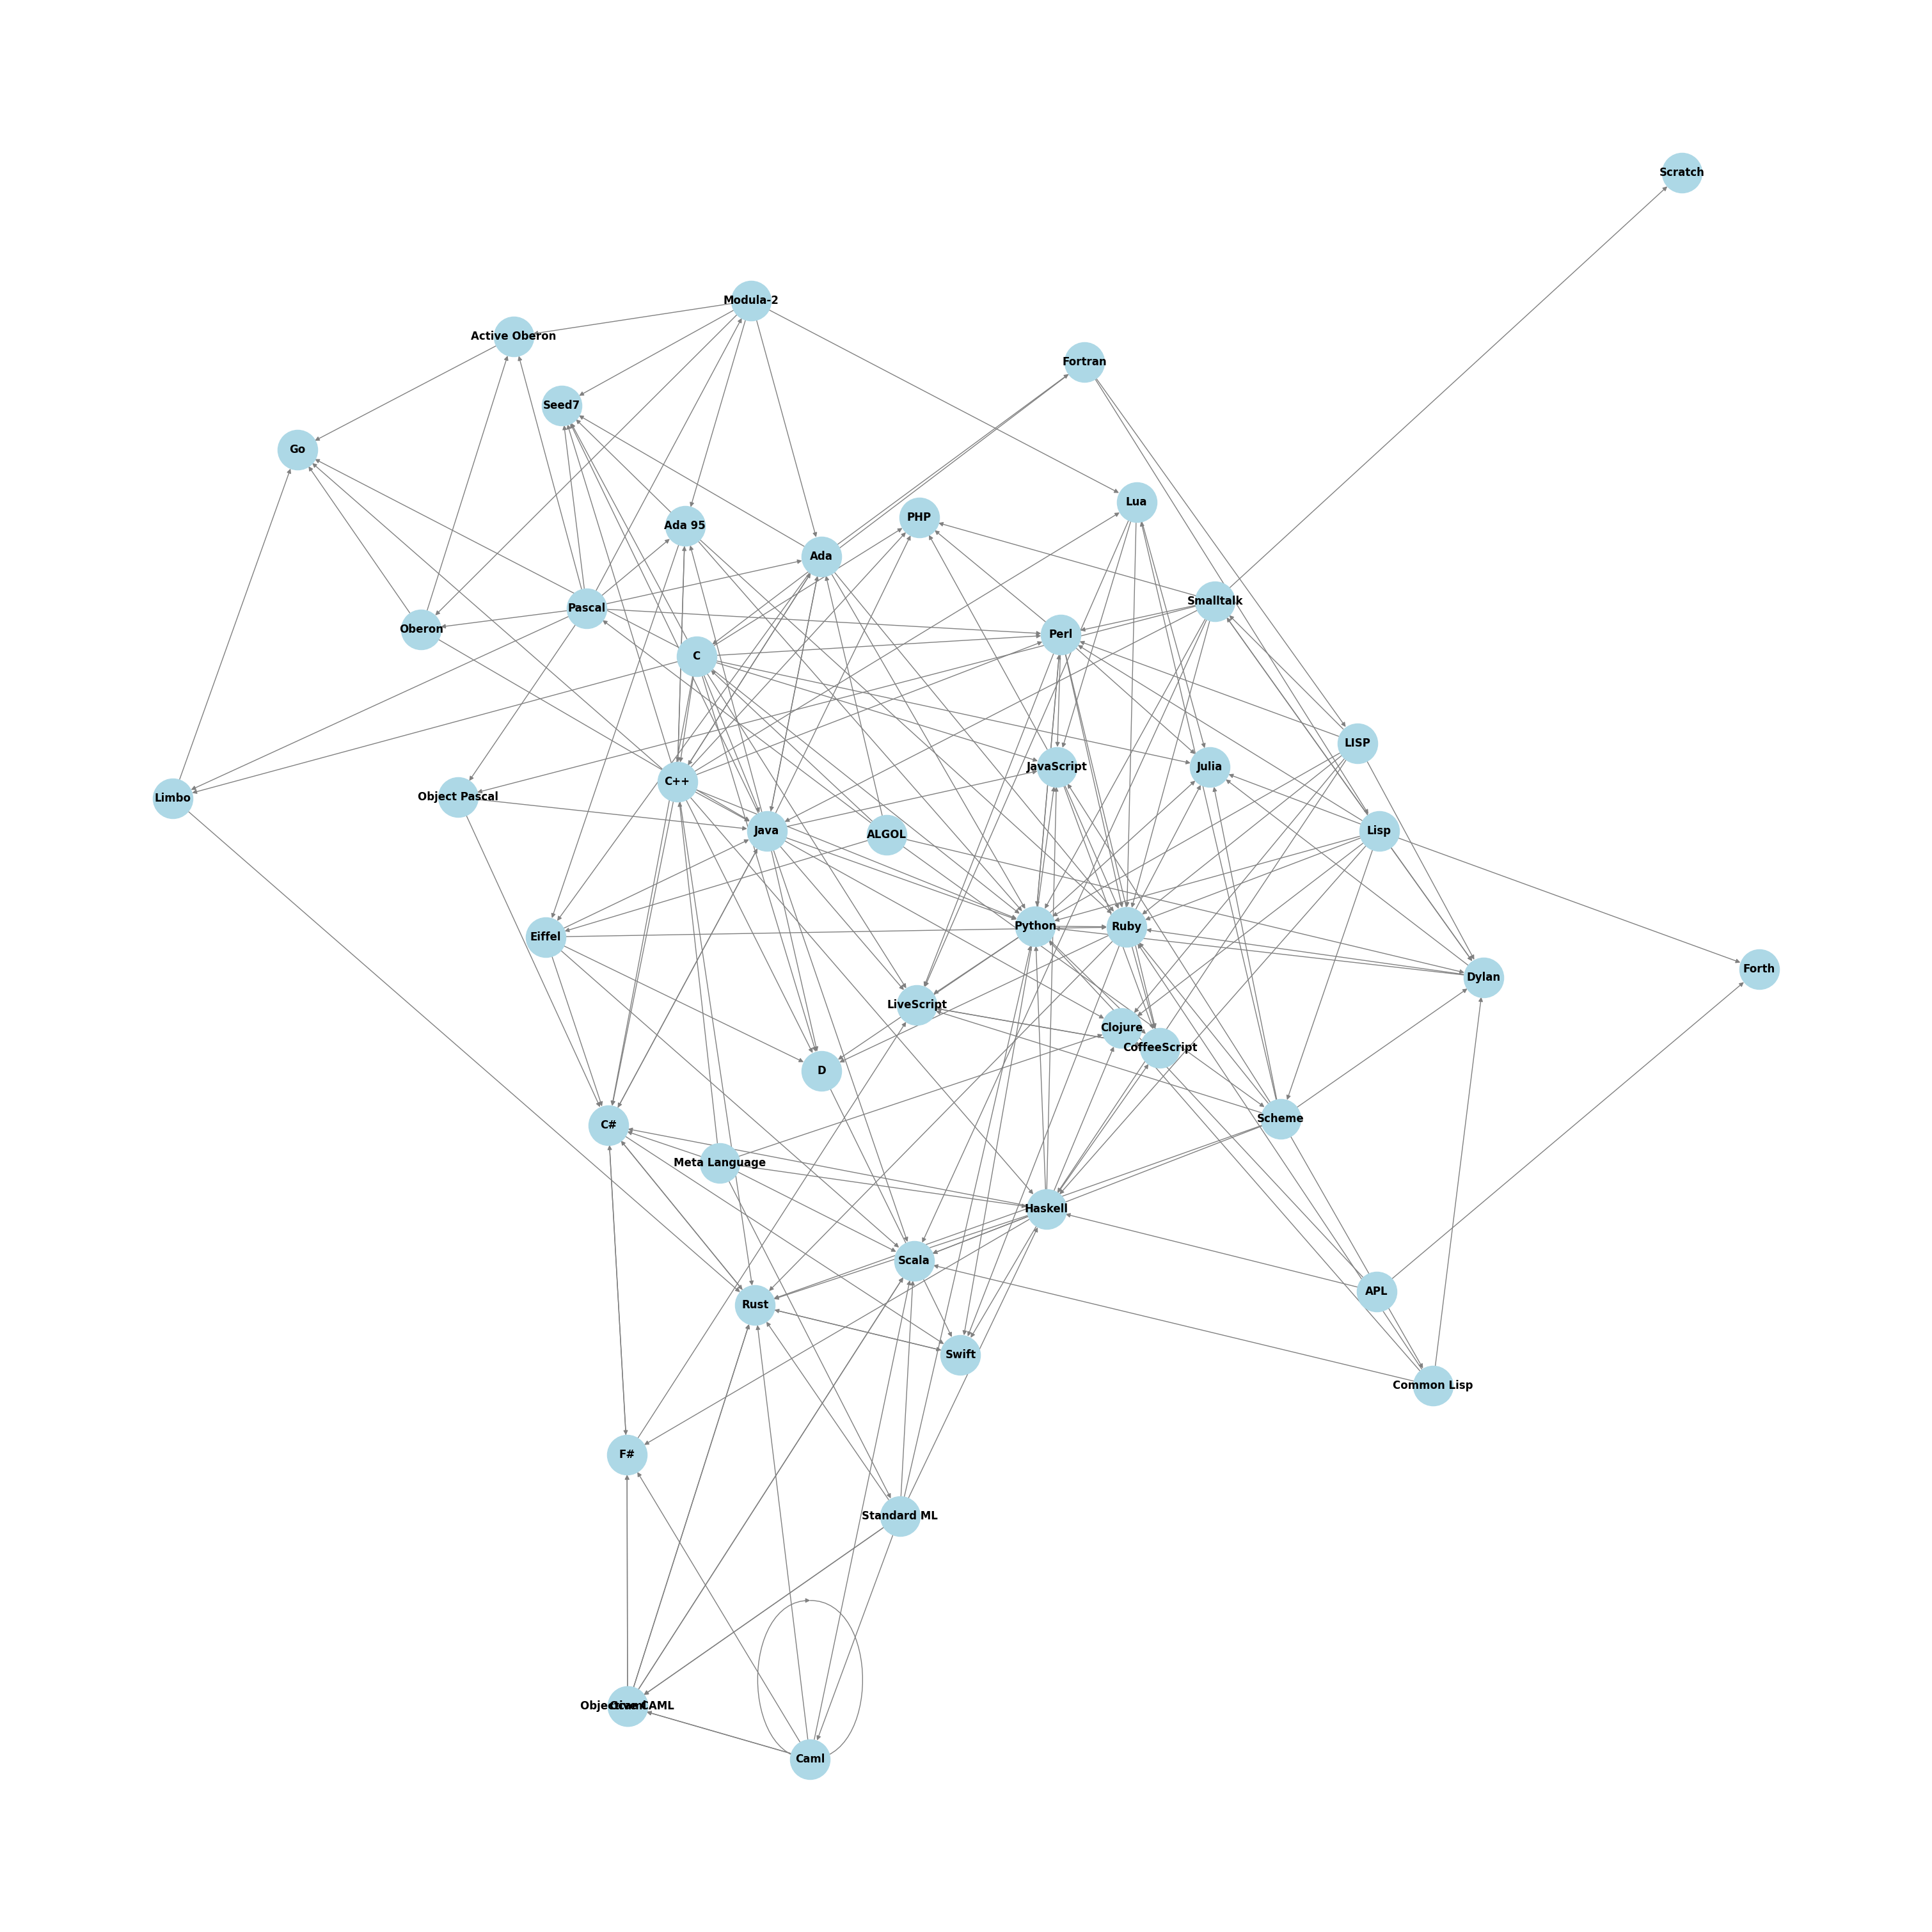

In [9]:
plt.figure(figsize=(30, 30))
pos = nx.kamada_kawai_layout(G)
nx.draw(G, pos, with_labels=True, node_color="lightblue", edge_color="gray", node_size=2000, font_size=12, font_weight="bold", arrows=True)
plt.show()